In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from PIL import Image
import os
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform = None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths=[os.path.join(root_dir, img) for img in os.listdir(root_dir) if img.endswith('.jpg')]
    
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


In [3]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std= [0.5,0.5,0.5])
])

In [4]:
dataset_path =r'/Users/t08/works/deep_advance/data/celeba'
dataset = CelebADataset(root_dir=dataset_path, transform = transform)
dataloader = DataLoader(dataset, batch_size = 128, shuffle = True)
print(f"Total number of images loaded: {len(dataset)}")

Total number of images loaded: 32600


In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim = 100, img_channels =3):
        super(Generator,self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256,512),
            nn.ReLU(True),
            nn.Linear(512,1024),
            nn.ReLU(True),
            nn.Linear(1024, img_channels * 64 * 64),
            nn.Tanh()
        )
    
    def forward(self,z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64)
        return img

class Discriminator(nn.Module):
    def __init__(self, img_channels = 3):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels * 64* 64, 1024),
            nn.LeakyReLU(0.2,inplace = True),
            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace = True),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace = True),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
    def forward(self, img):
        return self.model(img)

In [6]:
adversarial_loss = nn.BCELoss()
generator = Generator(z_dim = 100)
discriminator = Discriminator()

optimizer_G = optim.Adam(generator.parameters(), lr = 0.0002, betas = (0.5, 0.999))
optimizer_D = optim.Adam(generator.parameters(), lr = 0.0002, betas = (0.5, 0.999))

device = torch.device('mps')
generator= generator.to(device)
discriminator = discriminator.to(device)

In [10]:
def save_generated_images(generator, epoch, device, num_images = 16):
    z = torch.randn(num_images, 100).to(device)
    generated_imgs = generator(z).detach().cpu()
    grid = torchvision.utils.make_grid(generated_imgs, nrow= 4, normalize= True)
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.title(f"epoch {epoch}")
    plt.axis('off')
    plt.show()

def train(generator, discriminator, dataloader, epochs = 5):
    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)
            valid = torch.ones(batch_size, 1).to(device)
            fake = torch.zeros(batch_size, 1).to(device)

            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs), valid)
            fake_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device)).detach()),fake)
            d_loss = (real_loss + fake_loss) /2
            d_loss.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device))), valid)
            g_loss.backward()
            optimizer_G.step()

            if i % 50 ==0:
                print(f"[epoch{epoch + 1} / {epochs}] [Batch {i} / {len(dataloader)}] [D_loss : {d_loss.item()}] [G loss: {g_loss.item()}]")
        
        save_generated_images(generator, epoch, device)


[epoch1 / 20] [Batch 0 / 255] [D_loss : 1.8472670316696167] [G loss: 0.05271102860569954]
[epoch1 / 20] [Batch 50 / 255] [D_loss : 1.8479300737380981] [G loss: 0.05266401916742325]
[epoch1 / 20] [Batch 100 / 255] [D_loss : 1.8474104404449463] [G loss: 0.0526573583483696]
[epoch1 / 20] [Batch 150 / 255] [D_loss : 1.8479576110839844] [G loss: 0.05260906741023064]
[epoch1 / 20] [Batch 200 / 255] [D_loss : 1.8483076095581055] [G loss: 0.05259883776307106]
[epoch1 / 20] [Batch 250 / 255] [D_loss : 1.8485591411590576] [G loss: 0.05259372293949127]


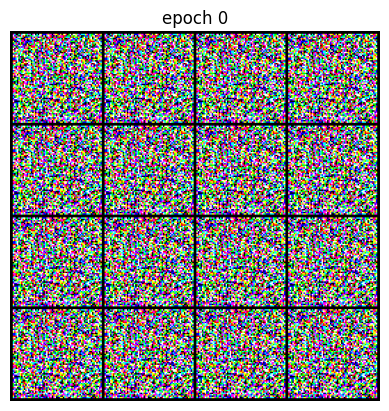

[epoch2 / 20] [Batch 0 / 255] [D_loss : 1.8483906984329224] [G loss: 0.052584148943424225]
[epoch2 / 20] [Batch 50 / 255] [D_loss : 1.8483750820159912] [G loss: 0.05258263647556305]
[epoch2 / 20] [Batch 100 / 255] [D_loss : 1.8484690189361572] [G loss: 0.05257217958569527]
[epoch2 / 20] [Batch 150 / 255] [D_loss : 1.8482937812805176] [G loss: 0.05258076637983322]
[epoch2 / 20] [Batch 200 / 255] [D_loss : 1.8490614891052246] [G loss: 0.05256691575050354]
[epoch2 / 20] [Batch 250 / 255] [D_loss : 1.849086046218872] [G loss: 0.05255585536360741]


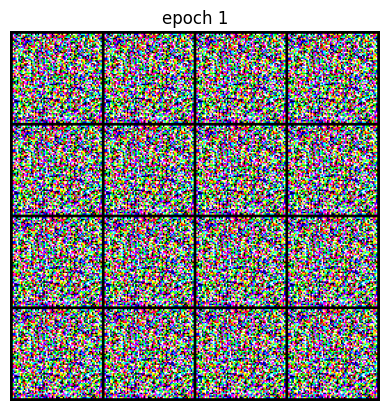

[epoch3 / 20] [Batch 0 / 255] [D_loss : 1.8488941192626953] [G loss: 0.05254508554935455]
[epoch3 / 20] [Batch 50 / 255] [D_loss : 1.8489928245544434] [G loss: 0.0525360181927681]


KeyboardInterrupt: 

In [9]:
train(generator, discriminator, dataloader, epochs=20)